In [1]:
import tsdm
import pandas
import numpy as np

In [2]:
from tsdm.datasets import Electricity

In [3]:
vars(Electricity)

mappingproxy({'__module__': 'tsdm.datasets.electricity',
              '__annotations__': {'url': 'str',
               'info_url': 'str',
               'dataset': 'DataFrame',
               'rawdata_path': 'Path',
               'dataset_path': 'Path',
               'dataset_file': 'Path'},
              '__doc__': 'Data set containing electricity consumption of 370 points/clients.\n\n    +--------------------------------+------------------------+---------------------------+--------+-------------------------+------------+\n    | **Data Set Characteristics:**  | Time-Series            | **Number of Instances:**  | 370    | **Area:**               | Computer   |\n    +--------------------------------+------------------------+---------------------------+--------+-------------------------+------------+\n    | **Attribute Characteristics:** | Real                   | **Number of Attributes:** | 140256 | **Date Donated**        | 2015-03-13 |\n    +--------------------------------+------

In [4]:
x = Electricity.dataset
x[pandas.Timestamp("2014-09-01") :].index[-1] - x[
    pandas.Timestamp("2014-09-01") :
].index[0], x[pandas.Timestamp("2014-03-31") :].index[-1] - x[
    pandas.Timestamp("2014-03-31") :
].index[
    0
]

(Timedelta('122 days 00:00:00'), Timedelta('276 days 00:00:00'))

In [5]:
observed = np.random.choice([True, False], size=x.shape)
x = x.where(observed)
display(observed, x)

array([[False, False, False, ..., False, False,  True],
       [ True,  True,  True, ...,  True, False,  True],
       [False,  True, False, ..., False, False,  True],
       ...,
       [ True, False,  True, ...,  True, False, False],
       [False, False,  True, ..., False,  True, False],
       [ True,  True, False, ...,  True,  True,  True]])

client,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
time,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,NaN,NaN,NaN,0.000000,NaN,NaN,0.00000,NaN,NaN,0.000000,...,0.000000,NaN,0.000000,0.000000,0.000000,NaN,0.000000,NaN,NaN,0.000000
2011-01-01 00:30:00,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.0,0.000000,...,0.000000,NaN,0.000000,NaN,0.000000,0.000000,NaN,0.000000,NaN,0.000000
2011-01-01 00:45:00,NaN,0.000000,NaN,NaN,0.000000,0.000000,0.00000,0.000000,0.0,NaN,...,NaN,0.0,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000
2011-01-01 01:00:00,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0,NaN,...,0.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01 01:15:00,NaN,NaN,NaN,0.000000,0.000000,NaN,0.00000,NaN,NaN,NaN,...,0.000000,0.0,0.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-31 23:00:00,2.538071,NaN,NaN,150.406504,85.365854,NaN,NaN,282.828283,NaN,72.043011,...,NaN,NaN,1616.033755,NaN,NaN,NaN,NaN,NaN,651.026393,7621.621622
2014-12-31 23:15:00,NaN,21.337127,NaN,NaN,81.707317,NaN,NaN,252.525253,NaN,NaN,...,NaN,NaN,NaN,NaN,29.986962,9.947338,671.641791,NaN,NaN,6702.702703
2014-12-31 23:30:00,2.538071,NaN,1.737619,162.601626,NaN,318.452381,NaN,NaN,NaN,74.193548,...,284.796574,27800.0,1556.962025,1318.181818,27.379400,NaN,670.763828,153.589316,NaN,NaN


### 2.1 Triplet Format

The data is represented as a set of triplets (time, variable, value). All NaNs are dropped.

In [6]:
dense_x = tsdm.encoders.make_dense_triplets(x)
dense_x

,variable,value
time,,
2011-01-01 00:15:00,MT_004,0.000000
2011-01-01 00:15:00,MT_007,0.000000
2011-01-01 00:15:00,MT_010,0.000000
2011-01-01 00:15:00,MT_012,0.000000
2011-01-01 00:15:00,MT_014,0.000000
...,...,...
2015-01-01 00:00:00,MT_365,27.379400
2015-01-01 00:00:00,MT_366,4.095963
2015-01-01 00:00:00,MT_368,131.886477


### 2.2 Sparse Triplet format

The same as before, but the variable tensor is encoded in a one-hot fashion, and the tensor is stored as a sparse tensor

In [7]:
sparse_x = tsdm.encoders.make_sparse_triplets(x)
sparse_x

,value,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
time,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,0.000000,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-01-01 00:15:00,0.000000,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-01-01 00:15:00,0.000000,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-01-01 00:15:00,0.000000,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-01-01 00:15:00,0.000000,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-01-01 00:00:00,27.379400,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2015-01-01 00:00:00,4.095963,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2015-01-01 00:00:00,131.886477,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


### 2.3 Masked Format

Here we get 3 tensors:

- x: the original data
- m: a boolean mask, 1: value observed, 0: value not observed (NaN)
- d: time since the channel was last observed

In [8]:
x, m, d = tsdm.encoders.make_masked_format(x)
display(x, m, d)

client,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
time,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,NaN,NaN,NaN,0.000000,NaN,NaN,0.00000,NaN,NaN,0.000000,...,0.000000,NaN,0.000000,0.000000,0.000000,NaN,0.000000,NaN,NaN,0.000000
2011-01-01 00:30:00,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.0,0.000000,...,0.000000,NaN,0.000000,NaN,0.000000,0.000000,NaN,0.000000,NaN,0.000000
2011-01-01 00:45:00,NaN,0.000000,NaN,NaN,0.000000,0.000000,0.00000,0.000000,0.0,NaN,...,NaN,0.0,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000
2011-01-01 01:00:00,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0,NaN,...,0.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01 01:15:00,NaN,NaN,NaN,0.000000,0.000000,NaN,0.00000,NaN,NaN,NaN,...,0.000000,0.0,0.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-31 23:00:00,2.538071,NaN,NaN,150.406504,85.365854,NaN,NaN,282.828283,NaN,72.043011,...,NaN,NaN,1616.033755,NaN,NaN,NaN,NaN,NaN,651.026393,7621.621622
2014-12-31 23:15:00,NaN,21.337127,NaN,NaN,81.707317,NaN,NaN,252.525253,NaN,NaN,...,NaN,NaN,NaN,NaN,29.986962,9.947338,671.641791,NaN,NaN,6702.702703
2014-12-31 23:30:00,2.538071,NaN,1.737619,162.601626,NaN,318.452381,NaN,NaN,NaN,74.193548,...,284.796574,27800.0,1556.962025,1318.181818,27.379400,NaN,670.763828,153.589316,NaN,NaN


client,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
time,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,0,0,0,1,0,0,1,0,0,1,...,1,0,1,1,1,0,1,0,0,1
2011-01-01 00:30:00,1,1,1,0,0,0,0,0,1,1,...,1,0,1,0,1,1,0,1,0,1
2011-01-01 00:45:00,0,1,0,0,1,1,1,1,1,0,...,0,1,0,1,1,1,1,0,0,1
2011-01-01 01:00:00,0,0,1,1,1,1,1,1,1,0,...,1,1,0,0,0,0,0,0,0,0
2011-01-01 01:15:00,0,0,0,1,1,0,1,0,0,0,...,1,1,1,0,0,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-31 23:00:00,1,0,0,1,1,0,0,1,0,1,...,0,0,1,0,0,0,0,0,1,1
2014-12-31 23:15:00,0,1,0,0,1,0,0,1,0,0,...,0,0,0,0,1,1,1,0,0,1
2014-12-31 23:30:00,1,0,1,1,0,1,0,0,0,1,...,1,1,1,1,1,0,1,1,0,0


client,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
time,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,...,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00
2011-01-01 00:30:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,...,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00
2011-01-01 00:45:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:30:00,0 days 00:30:00,0 days 00:30:00,0 days 00:30:00,0 days 00:30:00,0 days 00:15:00,0 days 00:15:00,...,0 days 00:15:00,0 days 00:30:00,0 days 00:15:00,0 days 00:30:00,0 days 00:15:00,0 days 00:15:00,0 days 00:30:00,0 days 00:15:00,0 days 00:30:00,0 days 00:15:00
2011-01-01 01:00:00,0 days 00:30:00,0 days 00:15:00,0 days 00:30:00,0 days 00:45:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:30:00,...,0 days 00:30:00,0 days 00:15:00,0 days 00:30:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:30:00,0 days 00:45:00,0 days 00:15:00
2011-01-01 01:15:00,0 days 00:45:00,0 days 00:30:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:45:00,...,0 days 00:15:00,0 days 00:15:00,0 days 00:45:00,0 days 00:30:00,0 days 00:30:00,0 days 00:30:00,0 days 00:30:00,0 days 00:45:00,0 days 01:00:00,0 days 00:30:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-31 23:00:00,0 days 00:30:00,0 days 00:30:00,0 days 00:15:00,0 days 00:15:00,0 days 00:30:00,0 days 00:30:00,0 days 00:45:00,0 days 00:45:00,0 days 00:30:00,0 days 01:30:00,...,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:30:00,0 days 00:30:00,0 days 00:15:00,0 days 00:30:00,0 days 00:45:00
2014-12-31 23:15:00,0 days 00:15:00,0 days 00:45:00,0 days 00:30:00,0 days 00:15:00,0 days 00:15:00,0 days 00:45:00,0 days 01:00:00,0 days 00:15:00,0 days 00:45:00,0 days 00:15:00,...,0 days 00:30:00,0 days 00:30:00,0 days 00:15:00,0 days 00:30:00,0 days 00:30:00,0 days 00:45:00,0 days 00:45:00,0 days 00:30:00,0 days 00:15:00,0 days 00:15:00
2014-12-31 23:30:00,0 days 00:30:00,0 days 00:15:00,0 days 00:45:00,0 days 00:30:00,0 days 00:15:00,0 days 01:00:00,0 days 01:15:00,0 days 00:15:00,0 days 01:00:00,0 days 00:30:00,...,0 days 00:45:00,0 days 00:45:00,0 days 00:30:00,0 days 00:45:00,0 days 00:15:00,0 days 00:15:00,0 days 00:15:00,0 days 00:45:00,0 days 00:30:00,0 days 00:15:00


## 3. Visualizing the data

In [9]:
df = Electricity.dataset
ΔT = np.diff(df.index)
Δt = ΔT[0].astype("timedelta64[m]")
assert np.all(ΔT == Δt)
N, M = df.shape
# remove first year from the data (useless zeros)
span = np.timedelta64(365, "D") // Δt
df = df.iloc[span:]

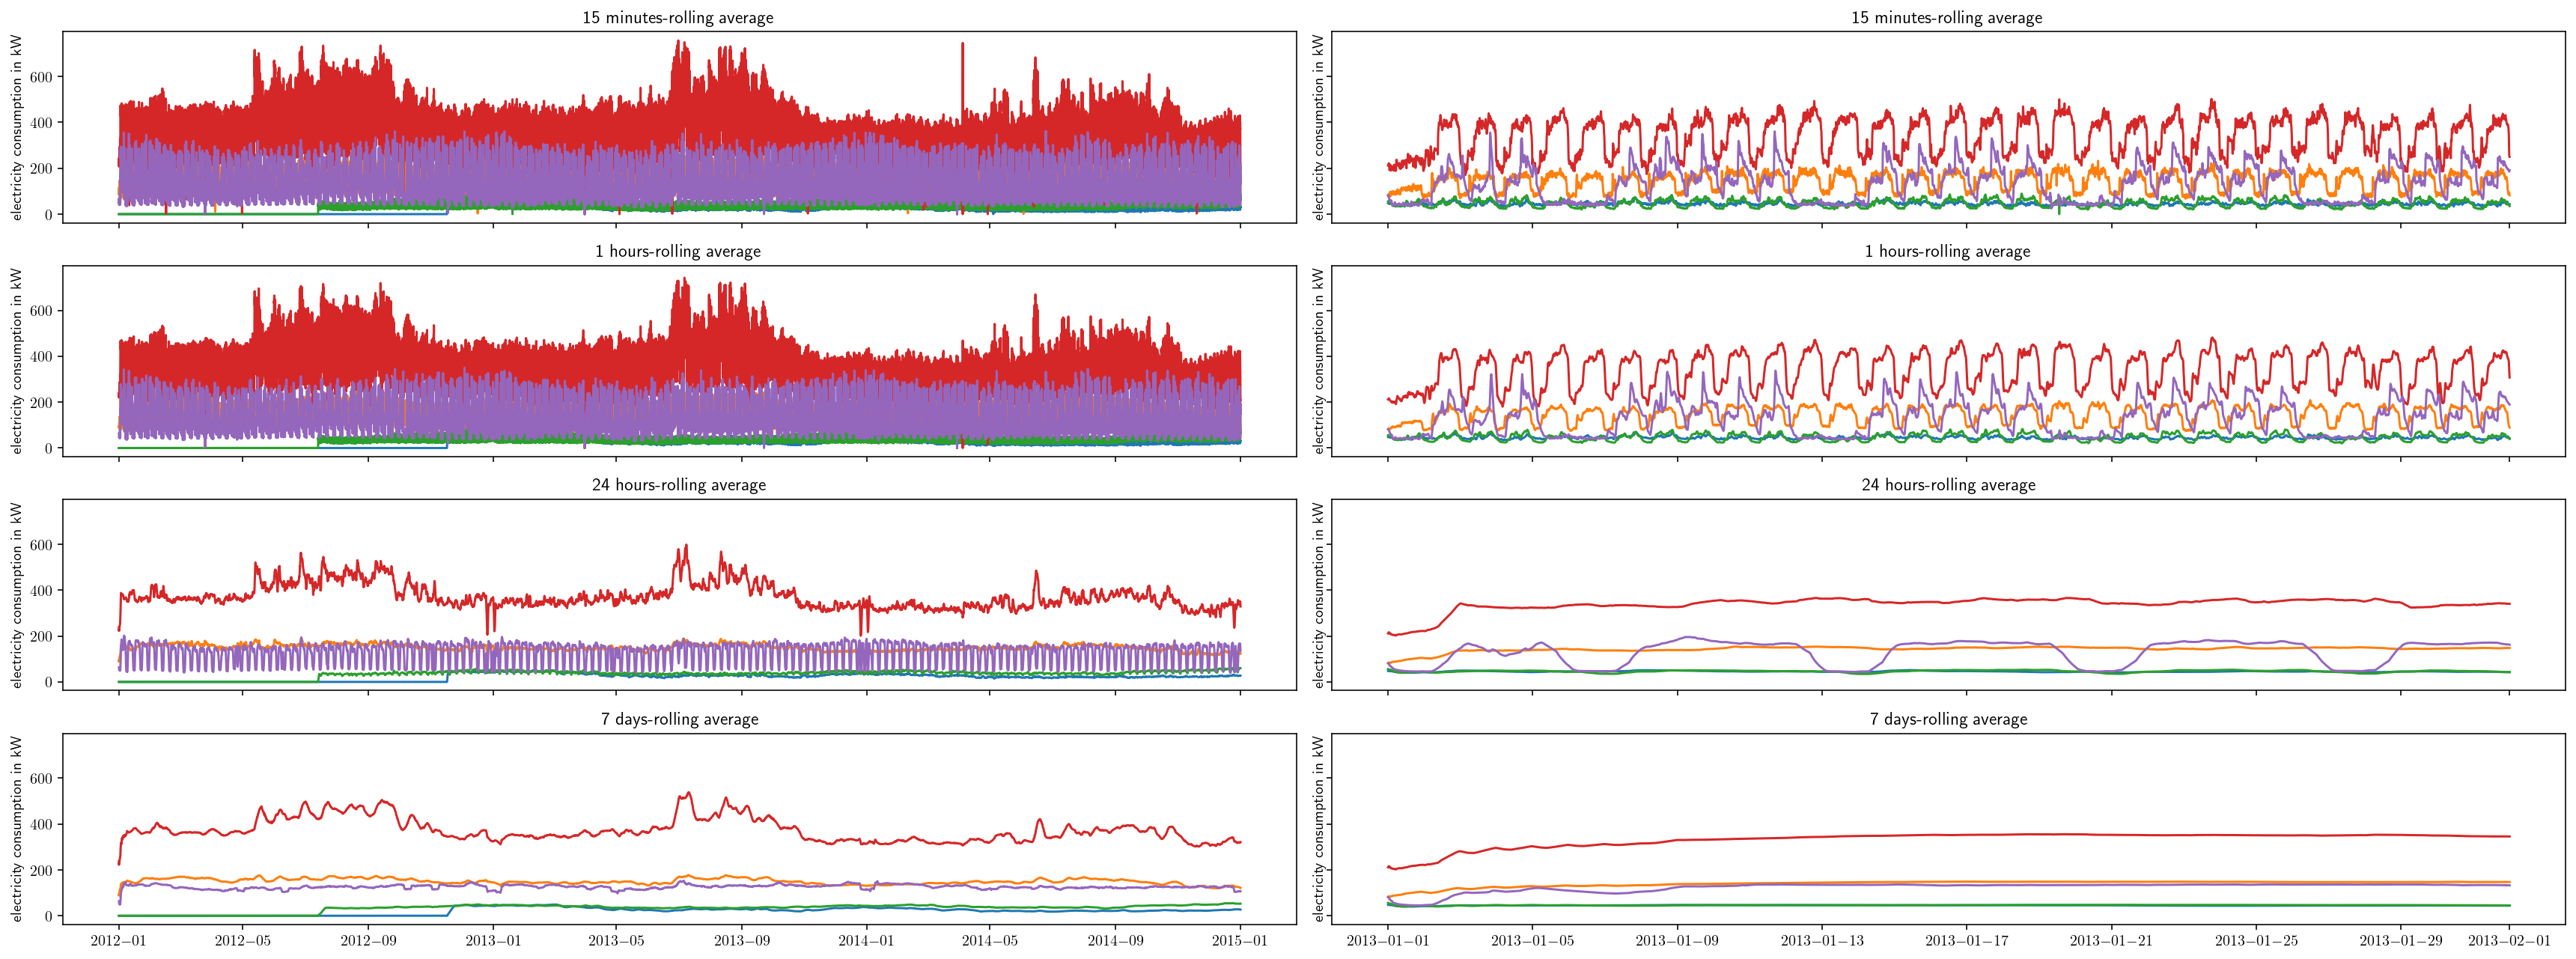

In [10]:
%config InlineBackend.figure_format = 'retina'
from matplotlib import pyplot as plt

fig, ax = plt.subplots(
    nrows=4, ncols=2, figsize=(24, 9), tight_layout=True, sharex="col", sharey=True
)
ax[1, 0].set_title("1h rolling average")
ax[1, 0].set_title("24h rolling average")
ax[2, 0].set_title("7d rolling average")
selection = np.random.randint(low=0, high=M, size=5)
# selection = [319]

a = np.datetime64("2013-01-01")
b = np.datetime64("2013-02-01")
mask = (df.index >= a) & (df.index <= b)


for k, timedelta in enumerate(
    (Δt, np.timedelta64(1, "h"), np.timedelta64(24, "h"), np.timedelta64(7, "D"))
):
    for l in range(2):
        if l == 0:
            data = df.rolling(window=timedelta // Δt, min_periods=1, axis=0).mean()
        if l == 1:
            a = np.datetime64("2013-01-01")
            b = np.datetime64("2013-02-01")
            mask = (df.index >= a) & (df.index <= b)
            data = (
                df[mask].rolling(window=timedelta // Δt, min_periods=1, axis=0).mean()
            )

        for col in data.iloc[:, selection]:
            ax[k, l].plot(data.index, data[col])
        ax[k, l].set_title(f"{timedelta}-rolling average")
        ax[k, l].set_ylabel("electricity consumption in kW")